In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPool1D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
import seaborn as sns

In [2]:
# dataset path 
path_mit_test = r'C:\DS-B3\MLinMedicine\practice 1\mitbih_test.csv'
path_mit_train = r'C:\DS-B3\MLinMedicine\practice 1\mitbih_train.csv'
path_ptb_norm = r'C:\DS-B3\MLinMedicine\practice 1\ptbdb_normal.csv'
path_ptb_abnorm = r'C:\DS-B3\MLinMedicine\practice 1\ptbdb_abnormal.csv'

# 1. 


1. MIT-BIH ARRHYTHMIA DATASET

Train set: 87554
Test set: 21892
Class distribution (train set):
  N (Normal): 72471 samples (82.8%)
  S: 2223 samples (2.5%)
  V: 5788 samples (6.6%)
  F: 641 samples (0.7%)
  Q: 6431 samples (7.3%)


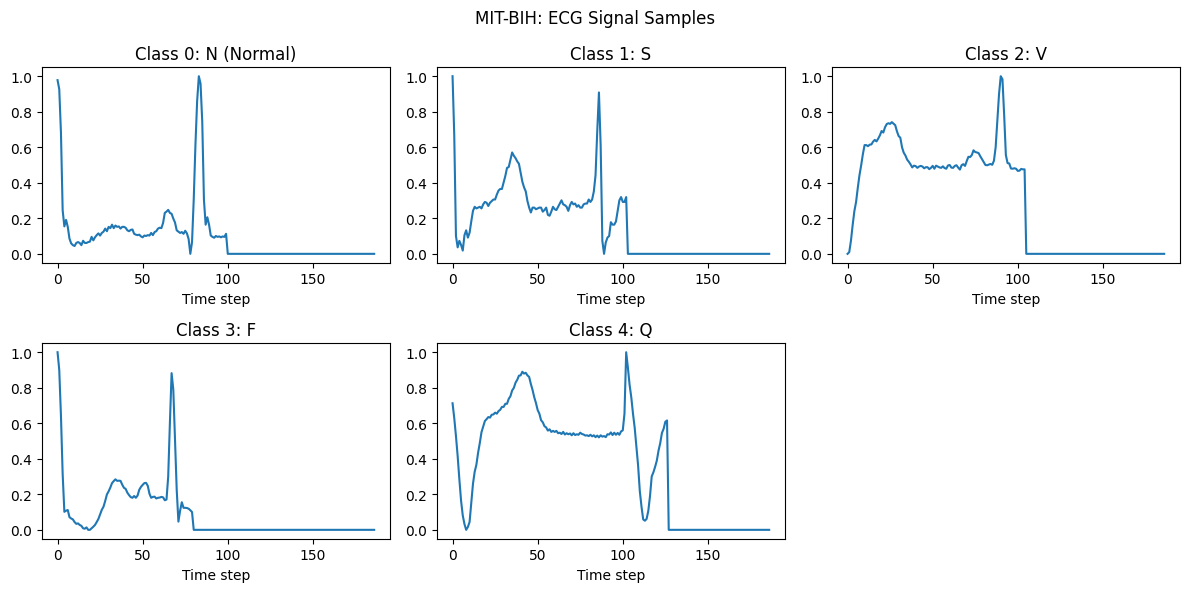

In [3]:
# 1.1 MIT-BIH Dataset
print("\n1. MIT-BIH ARRHYTHMIA DATASET")
df_mit_train = pd.read_csv(path_mit_train, header=None)
df_mit_test = pd.read_csv(path_mit_test, header=None)

# class distribution 
labels_mit = df_mit_train.iloc[:, 187].values
unique, counts = np.unique(labels_mit, return_counts=True)
class_names = ['N (Normal)', 'S', 'V', 'F', 'Q']

print(f"\nTrain set: {len(df_mit_train)}")
print(f"Test set: {len(df_mit_test)}")
print(f"Class distribution (train set):")
for i, (cls, count) in enumerate(zip(unique, counts)):
    print(f"  {class_names[i]}: {count} samples ({count/len(df_mit_train)*100:.1f}%)")

# sample ECG signals 
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.ravel()
for i in range(5):
    sample = df_mit_train[df_mit_train.iloc[:, 187] == i].iloc[0, :187].values
    axes[i].plot(sample)
    axes[i].set_title(f'Class {i}: {class_names[i]}')
    axes[i].set_xlabel('Time step')
axes[5].axis('off')
plt.suptitle('MIT-BIH: ECG Signal Samples')
plt.tight_layout()
plt.savefig('mitbih_samples.png', dpi=150)
plt.show()


2. PTB DIAGNOSTIC DATASET

Normal samples: 4046
Abnormal samples: 10506
Total: 14552


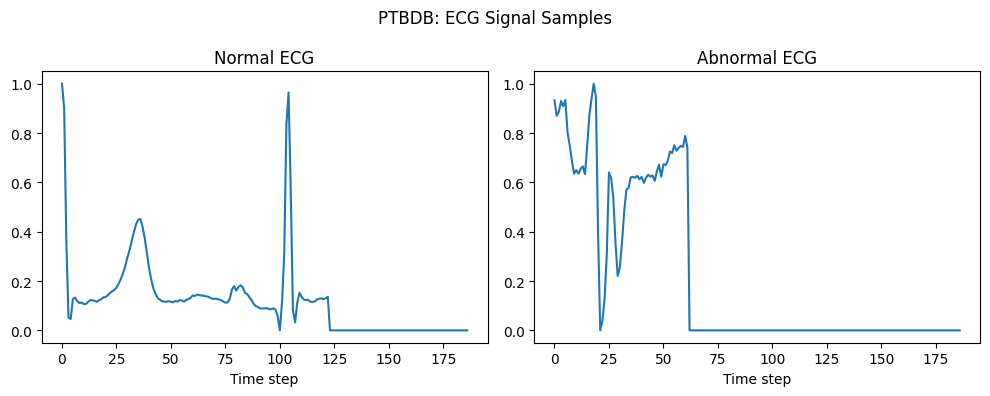

In [4]:
# 1.2 PTBDB Dataset
print("\n2. PTB DIAGNOSTIC DATASET")
df_norm = pd.read_csv(path_ptb_norm, header=None)
df_abnorm = pd.read_csv(path_ptb_abnorm, header=None)

print(f"\nNormal samples: {len(df_norm)}")
print(f"Abnormal samples: {len(df_abnorm)}")
print(f"Total: {len(df_norm) + len(df_abnorm)}")

# PTBDB samples
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(df_norm.iloc[0, :187].values)
ax1.set_title('Normal ECG')
ax1.set_xlabel('Time step')
ax2.plot(df_abnorm.iloc[0, :187].values)
ax2.set_title('Abnormal ECG')
ax2.set_xlabel('Time step')
plt.suptitle('PTBDB: ECG Signal Samples')
plt.tight_layout()
plt.savefig('ptbdb_samples.png', dpi=150)
plt.show()


# 2. Build model  

In [5]:
def create_model(num_classes):
    model = Sequential([
        Conv1D(64, 6, activation='relu', input_shape=(187, 1)),
        BatchNormalization(),
        MaxPool1D(3, 2),
        Conv1D(64, 3, activation='relu'),
        BatchNormalization(),
        MaxPool1D(2, 2),
        Flatten(),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(num_classes, activation='softmax')
    ])
    model.compile('adam', 'categorical_crossentropy', metrics=['accuracy'])
    return model

# 3. Train MIT-BIH 

In [6]:
# Prepare the data 
X_mit_train = df_mit_train.iloc[:, :187].values.reshape(-1, 187, 1)
y_mit_train = to_categorical(df_mit_train.iloc[:, 187])
X_mit_test = df_mit_test.iloc[:, :187].values.reshape(-1, 187, 1)
y_mit_test = to_categorical(df_mit_test.iloc[:, 187])

# Train
model_mit = create_model(5)
history_mit = model_mit.fit(
    X_mit_train, y_mit_train,
    epochs=5,
    batch_size=64,
    validation_data=(X_mit_test, y_mit_test),
    verbose=1
)

# Results 
train_acc = history_mit.history['accuracy'][-1] * 100
val_acc = history_mit.history['val_accuracy'][-1] * 100
print(f"\nMIT-BIH Results:")
print(f"Training Accuracy: {train_acc:.2f}%")
print(f"Validation Accuracy: {val_acc:.2f}%")


c:\Users\ADMIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1369/1369 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9333 - loss: 0.2478 - val_accuracy: 0.9663 - val_loss: 0.1302
Epoch 2/5
1369/1369 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.9725 - loss: 0.0976 - val_accuracy: 0.9627 - val_loss: 0.1380
Epoch 3/5
1369/1369 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.9786 - loss: 0.0730 - val_accuracy: 0.9787 - val_loss: 0.0798
Epoch 4/5
1369/1369 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9812 - loss: 0.0616 - val_accuracy: 0.9776 - val_loss: 0.0923
Epoch 5/5
1369/1369 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9836 - loss: 0.0537 - val_accuracy: 0.9724 - val_loss: 0.1051

MIT-BIH Results:
Training Accuracy: 98.39%
Validation Accuracy: 97.24%


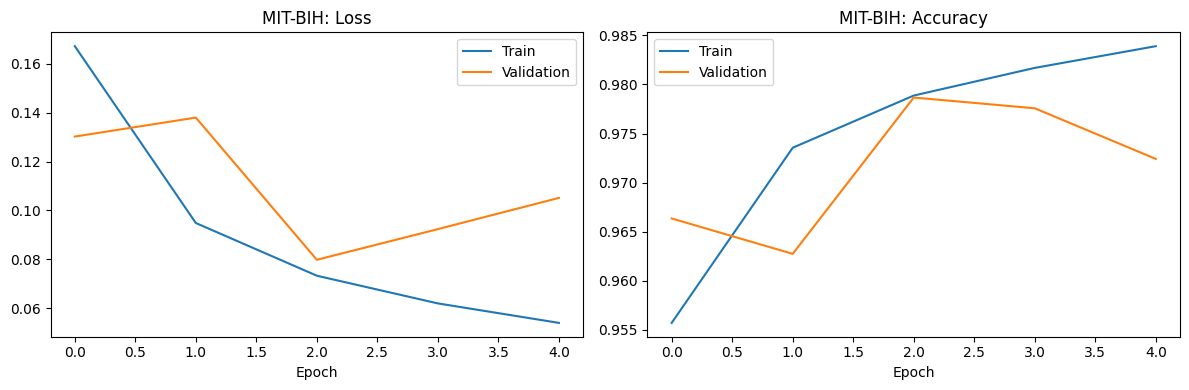

685/685 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


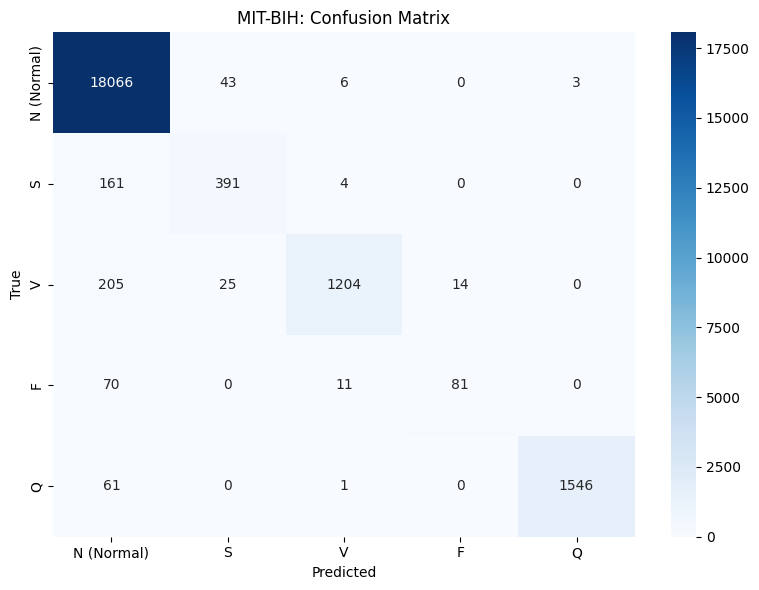

In [7]:
# training plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history_mit.history['loss'], label='Train')
ax1.plot(history_mit.history['val_loss'], label='Validation')
ax1.set_title('MIT-BIH: Loss')
ax1.set_xlabel('Epoch')
ax1.legend()
ax2.plot(history_mit.history['accuracy'], label='Train')
ax2.plot(history_mit.history['val_accuracy'], label='Validation')
ax2.set_title('MIT-BIH: Accuracy')
ax2.set_xlabel('Epoch')
ax2.legend()
plt.tight_layout()
plt.savefig('mitbih_training.png', dpi=150)
plt.show()

# Confusion Matrix
y_pred = model_mit.predict(X_mit_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_mit_test, axis=1)

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_true, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('MIT-BIH: Confusion Matrix')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('mitbih_cm.png', dpi=150)
plt.show()

# 4. Train PTBDB 

In [8]:
# prepare the data 
df_ptb = pd.concat([df_norm, df_abnorm], ignore_index=True)
X_ptb = df_ptb.iloc[:, :187].values.reshape(-1, 187, 1)
y_ptb = to_categorical(df_ptb.iloc[:, 187])

# Train-test split
X_ptb_train, X_ptb_test, y_ptb_train, y_ptb_test = train_test_split(
    X_ptb, y_ptb, test_size=0.2, random_state=42, stratify=y_ptb
)

# Train
model_ptb = create_model(2)
history_ptb = model_ptb.fit(
    X_ptb_train, y_ptb_train,
    epochs=5,
    batch_size=64,
    validation_data=(X_ptb_test, y_ptb_test),
    verbose=1
)

# Results 
train_acc_ptb = history_ptb.history['accuracy'][-1] * 100
val_acc_ptb = history_ptb.history['val_accuracy'][-1] * 100
print(f"\nPTBDB Results:")
print(f"Training Accuracy: {train_acc_ptb:.2f}%")
print(f"Validation Accuracy: {val_acc_ptb:.2f}%")

Epoch 1/5


c:\Users\ADMIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


182/182 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8062 - loss: 0.4425 - val_accuracy: 0.7221 - val_loss: 0.6521
Epoch 2/5
182/182 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9340 - loss: 0.1701 - val_accuracy: 0.7224 - val_loss: 0.8948
Epoch 3/5
182/182 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9678 - loss: 0.0893 - val_accuracy: 0.8595 - val_loss: 0.2894
Epoch 4/5
182/182 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9710 - loss: 0.0729 - val_accuracy: 0.9481 - val_loss: 0.1336
Epoch 5/5
182/182 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9791 - loss: 0.0552 - val_accuracy: 0.9134 - val_loss: 0.2183

PTBDB Results:
Training Accuracy: 98.08%
Validation Accuracy: 91.34%


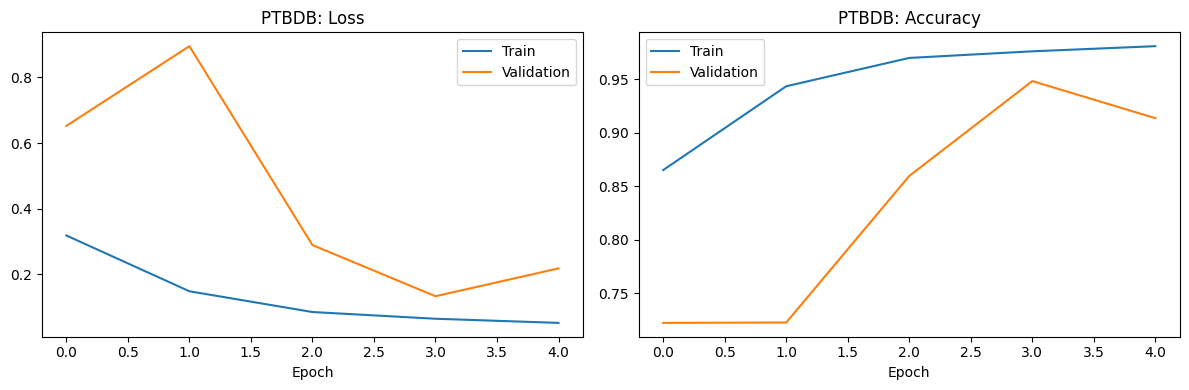

91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


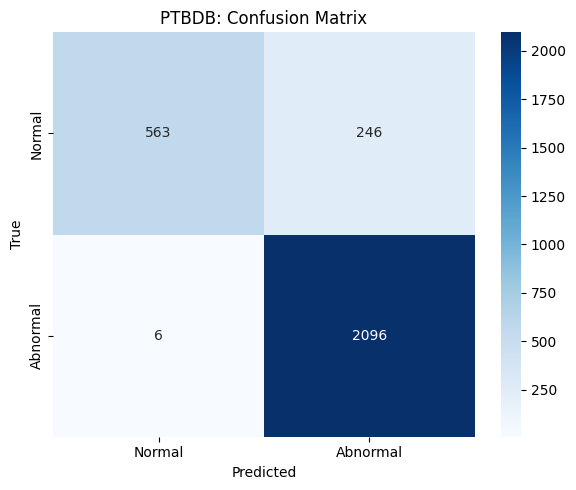

In [9]:
# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history_ptb.history['loss'], label='Train')
ax1.plot(history_ptb.history['val_loss'], label='Validation')
ax1.set_title('PTBDB: Loss')
ax1.set_xlabel('Epoch')
ax1.legend()
ax2.plot(history_ptb.history['accuracy'], label='Train')
ax2.plot(history_ptb.history['val_accuracy'], label='Validation')
ax2.set_title('PTBDB: Accuracy')
ax2.set_xlabel('Epoch')
ax2.legend()
plt.tight_layout()
plt.savefig('ptbdb_training.png', dpi=150)
plt.show()

# Confusion Matrix PTBDB
y_pred_ptb = model_ptb.predict(X_ptb_test)
y_pred_classes_ptb = np.argmax(y_pred_ptb, axis=1)
y_true_ptb = np.argmax(y_ptb_test, axis=1)

plt.figure(figsize=(6, 5))
cm_ptb = confusion_matrix(y_true_ptb, y_pred_classes_ptb)
sns.heatmap(cm_ptb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Abnormal'], 
            yticklabels=['Normal', 'Abnormal'])
plt.title('PTBDB: Confusion Matrix')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('ptbdb_cm.png', dpi=150)
plt.show()


In [10]:
# saving result 
with open('results.txt', 'w') as f:
    f.write(f"MIT-BIH Accuracy: {val_acc:.2f}%\n")
    f.write(f"PTBDB Accuracy: {val_acc_ptb:.2f}%\n")

print("\nResult saved in results.txt")
print("Plot saved in: mitbih_samples.png, ptbdb_samples.png,")
print("mitbih_training.png, ptbdb_training.png,")
print("mitbih_cm.png, ptbdb_cm.png")


Result saved in results.txt
Plot saved in: mitbih_samples.png, ptbdb_samples.png,
mitbih_training.png, ptbdb_training.png,
mitbih_cm.png, ptbdb_cm.png
